# T1 — Tuning Random Forest
GridSearchCV trên `t1_train.csv` | cv=5 | scoring=accuracy

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

ROOT = Path('../../')
train = pd.read_csv(ROOT / 'data/processed/t1_train.csv')
X_train = train.drop(columns=['winner'])
y_train = train['winner']

sns.set_theme(style='whitegrid', font_scale=1.0)
plt.rcParams['figure.dpi'] = 110
C1, C2 = '#4C82C2', '#E07B54'

print(f'Train: {X_train.shape}  |  Target balance: {y_train.value_counts().to_dict()}')

Train: (40236, 58)  |  Target balance: {0: 20370, 1: 19866}


In [2]:
param_grid = {
    'n_estimators':     [100, 200, 300],
    'max_depth':        [None, 10, 20],
}

rf = RandomForestClassifier(random_state=42, n_jobs=-1)
gs = GridSearchCV(rf, param_grid, cv=5, scoring='accuracy', n_jobs=-1, verbose=1)
gs.fit(X_train, y_train)

print(f'Best params : {gs.best_params_}')
print(f'Best CV Acc : {gs.best_score_:.4f} ({gs.best_score_*100:.2f}%)')

Fitting 5 folds for each of 9 candidates, totalling 45 fits
Best params : {'max_depth': 10, 'n_estimators': 300}
Best CV Acc : 0.5233 (52.33%)


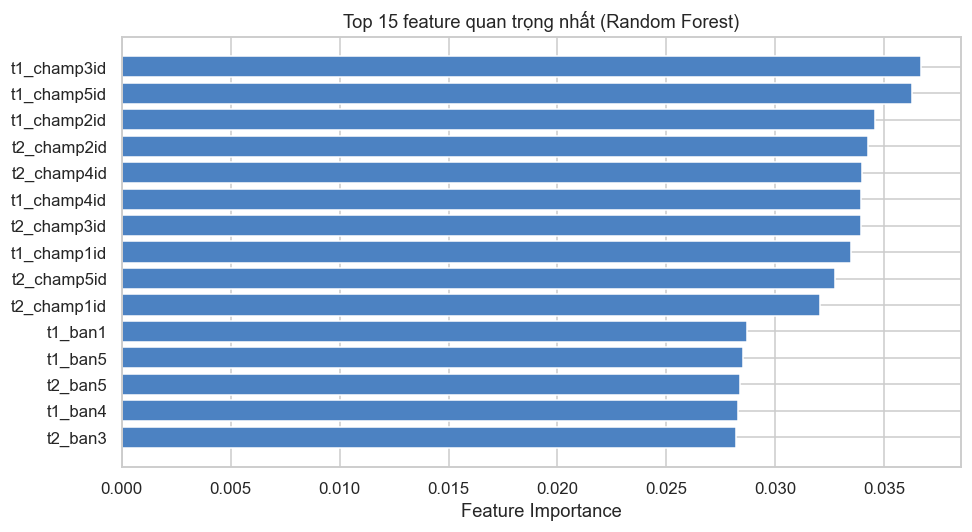

In [3]:
# Feature importance từ best model
best_rf = gs.best_estimator_
fi = pd.Series(best_rf.feature_importances_, index=X_train.columns)
top15_fi = fi.nlargest(15)

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(top15_fi.index[::-1], top15_fi.values[::-1], color=C1)
ax.set_xlabel('Feature Importance')
ax.set_title('Top 15 feature quan trọng nhất (Random Forest)')
plt.tight_layout()
plt.show()

In [4]:
print('=' * 55)
print('KET QUA - RANDOM FOREST')
print('=' * 55)
print(f'Best CV Accuracy : {gs.best_score_:.4f}  ({gs.best_score_*100:.2f}%)')
print(f'Best params      : {gs.best_params_}')
print()
print('=> Dung cho t1_train_best.py:')
print(f"BEST_MODEL  = 'rf'")
print(f"BEST_PARAMS = {{")
for k, v in gs.best_params_.items():
    print(f"    '{k}': {repr(v)},")
print(f"    'random_state': 42,")
print(f"    'n_jobs': -1,")
print(f"}}")

KET QUA - RANDOM FOREST
Best CV Accuracy : 0.5233  (52.33%)
Best params      : {'max_depth': 10, 'n_estimators': 300}

=> Dung cho t1_train_best.py:
BEST_MODEL  = 'rf'
BEST_PARAMS = {
    'max_depth': 10,
    'n_estimators': 300,
    'random_state': 42,
    'n_jobs': -1,
}
